# Grid Tutorial

This tutorial covers the **RegularGrid** class in `rompy-xbeach`, which defines
the computational domain for XBeach simulations.

![XBeach Grid Scheme](xbeach_grid_scheme.png)

*Image modified from the [XBeach documentation](https://xbeach.readthedocs.io/en/latest/xbeach_manual.html#grid-set-up)*

## What You'll Learn

1. Defining grid origin with `GeoPoint`
2. Creating a `RegularGrid` with orientation and resolution
3. Grid attributes and coordinate systems
4. Plotting grids with coastlines and projections
5. Expanding grids for boundary conditions
6. Saving and loading grids

## Prerequisites

- Basic understanding of coordinate reference systems (CRS)
- Familiarity with matplotlib and cartopy for plotting

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas
from shapely.geometry import shape

from rompy_xbeach.grid import GeoPoint, RegularGrid

import warnings
warnings.filterwarnings("ignore")

---
## 1. Grid Origin with GeoPoint

The grid origin is defined using a `GeoPoint` object, which holds coordinates
and their coordinate reference system (CRS). This allows defining the origin
in geographic (lat/lon) or projected coordinates.

In [2]:
# Define origin in WGS84 (EPSG:4326)
ori = GeoPoint(x=115.5875, y=-32.646, crs=4326)
ori

GeoPoint(x=115.5875, y=-32.646, crs='EPSG:4326')

### Reprojecting Coordinates

A `GeoPoint` can be reprojected to different coordinate systems:

In [3]:
# Reproject to MGA Zone 50 (EPSG:28350)
ori_projected = ori.reproject(28350)
print(f"Original (WGS84):    x={ori.x:.4f}, y={ori.y:.4f}")
print(f"Projected (MGA50):   x={ori_projected.x:.1f}, y={ori_projected.y:.1f}")

Original (WGS84):    x=115.5875, y=-32.6460
Projected (MGA50):   x=367520.1, y=6387075.4


In [4]:
# Reproject back to WGS84
ori_back = ori_projected.reproject(4326)
print(f"Back to WGS84:       x={ori_back.x:.4f}, y={ori_back.y:.4f}")

Back to WGS84:       x=115.5875, y=-32.6460


---
## 2. Creating a RegularGrid

The `RegularGrid` is defined by:
- **ori**: Grid origin (bottom-left corner, onshore side)
- **alfa**: Grid rotation angle (degrees from East, counter-clockwise)
- **dx, dy**: Cell dimensions in the grid's CRS units (typically metres)
- **nx, ny**: Number of cells in x (cross-shore) and y (alongshore) directions
- **crs**: Coordinate reference system for the grid

In [5]:
grid = RegularGrid(
    ori=GeoPoint(x=115.5875, y=-32.646, crs="epsg:4326"),
    alfa=344.0,  # Grid rotated 344° from East (roughly shore-normal)
    dx=10,       # 10m cross-shore resolution
    dy=20,       # 20m alongshore resolution
    nx=270,      # 270 cells cross-shore (2700m extent)
    ny=305,      # 305 cells alongshore (6100m extent)
    crs="28350", # MGA Zone 50 projection
)
grid

RegularGrid(ori=GeoPoint(x=115.5875, y=-32.646, crs='EPSG:4326'), alfa=344.0, dx=10.0, dy=20.0, nx=270, ny=305, crs='EPSG:28350')

**Note**: The origin can be specified in any CRS (here WGS84), but the grid
itself is constructed in the specified `crs` (here MGA Zone 50). The origin
is automatically reprojected.

---
## 3. Grid Attributes

The grid object provides many useful attributes for working with the domain.

### Origin Coordinates (in grid CRS)

In [6]:
# x0, y0 are the origin coordinates in the grid's CRS (regardless of ori's CRS)
print(f"Origin: x0={grid.x0:.1f}, y0={grid.y0:.1f}")

Origin: x0=367520.1, y0=6387075.4


### Key Locations

In [7]:
# Centre of the offshore boundary (useful for wave boundary extraction)
print(f"Offshore centre: {grid.offshore}")

# Centre of the grid
print(f"Grid centre: {grid.centre}")

Offshore centre: (368358.01343065855, 6389997.627881368)
Grid centre: (369650.91041169566, 6389626.895637793)


### Grid Dimensions

In [8]:
print(f"Shape: {grid.shape}")
print(f"Extent: {grid.nx * grid.dx}m (cross-shore) × {grid.ny * grid.dy}m (alongshore)")

Shape: (305, 270)
Extent: 2700.0m (cross-shore) × 6100.0m (alongshore)


### Coordinate Arrays

In [9]:
# Full coordinate arrays
print(f"X coordinates shape: {grid.x.shape}")
print(f"Y coordinates shape: {grid.y.shape}")

X coordinates shape: (305, 270)
Y coordinates shape: (305, 270)


### Projections and Transforms

In [10]:
# Stereographic projection centered on the grid origin (for plotting)
print(f"Projection: {grid.projection}")

# Cartopy transform for plotting grid data
print(f"Transform: {grid.transform}")

Projection: +proj=stere +ellps=WGS84 +lat_0=-32.646 +lon_0=115.5875 +x_0=0.0 +y_0=0.0 +no_defs +type=crs
Transform: PROJCRS["GDA94 / MGA zone 50",BASEGEOGCRS["GDA94",DATUM["Geocentric Datum of Australia 1994",ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4283]],CONVERSION["Map Grid of Australia zone 50",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",117,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",10000000,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["(E)",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["(N)",north,ORDER[2],LENGTHUNIT["metre",1]],USAGE[SCOPE

### GeoDataFrame Representation

In [11]:
# Each cell as a polygon in a GeoDataFrame
gdf = grid.gdf
print(f"GeoDataFrame with {len(gdf)} cells")
gdf.head()

GeoDataFrame with 1 cells


,geometry,Name
0,"MULTIPOLYGON (((367520.076 6387075.392, 367529...","{'grid_type': 'base', 'model_type': 'regular',..."


### Boundary Coordinates

Access coordinates of each grid boundary:

In [12]:
# Each returns (x_coords, y_coords) tuples
print(f"Front (offshore): {len(grid.front[0])} points")
print(f"Back (onshore):   {len(grid.back[0])} points")
print(f"Left:             {len(grid.left[0])} points")
print(f"Right:            {len(grid.right[0])} points")

Front (offshore): 305 points
Back (onshore):   305 points
Left:             270 points
Right:            270 points


---
## 4. Plotting the Grid

The `plot()` method provides flexible visualization with coastlines and projections.

### Basic Plot

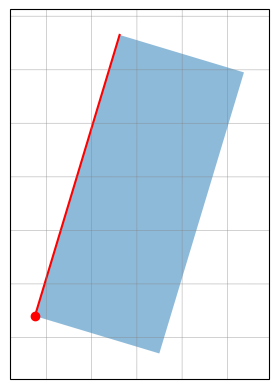

In [13]:
# Default plot shows grid extent with offshore boundary and origin highlighted
ax = grid.plot()

### Adding Coastlines

Coastlines use the GSHHS database with configurable resolution:
- `"c"` = crude, `"l"` = low, `"i"` = intermediate, `"h"` = high, `"f"` = full

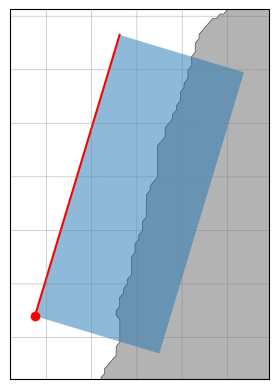

In [14]:
ax = grid.plot(scale="f")  # Full resolution coastline

### Showing the Grid Mesh

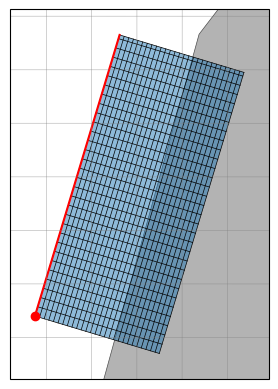

In [15]:
# Overlay the computational mesh (downsampled for clarity)
ax = grid.plot(scale="i", show_mesh=True, mesh_step=10)

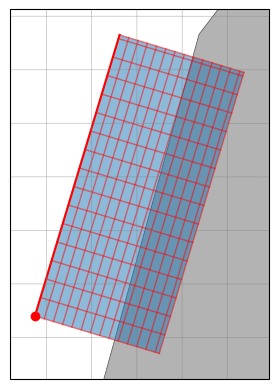

In [16]:
# Customise mesh appearance
ax = grid.plot(
    scale="i",
    show_mesh=True,
    mesh_step=20,
    mesh_kwargs=dict(color="red", alpha=0.5, linewidth=1.0),
)

### Highlighting Boundaries

Plot each boundary with different colours:

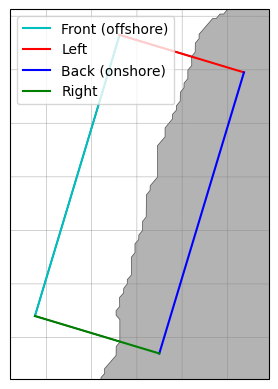

In [17]:
ax = grid.plot(
    scale="f",
    grid_kwargs=dict(facecolor="none"),
    show_origin=False,
    show_offshore=False,
)

# Plot each boundary
ax.plot(*grid.front, "c", transform=grid.transform, label="Front (offshore)")
ax.plot(*grid.left, "r", transform=grid.transform, label="Left")
ax.plot(*grid.back, "b", transform=grid.transform, label="Back (onshore)")
ax.plot(*grid.right, "g", transform=grid.transform, label="Right")
ax.legend(loc="upper left")

### Using Different Projections

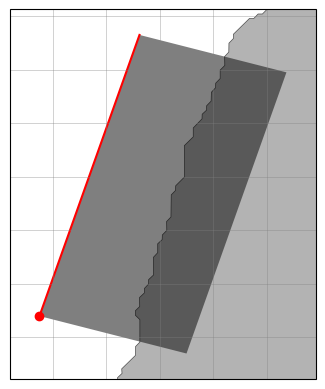

In [18]:
# Plot in PlateCarree (lat/lon) projection
ax = grid.plot(
    scale="f",
    projection=ccrs.PlateCarree(),
    grid_kwargs=dict(alpha=0.5, facecolor="black", zorder=2),
)

### Comparing Coastline Resolutions

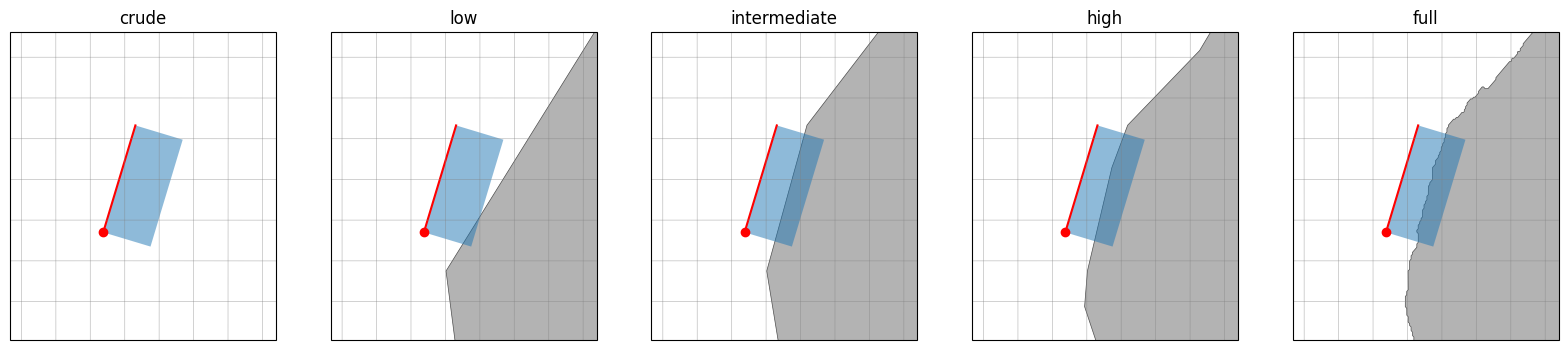

In [19]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4), subplot_kw=dict(projection=grid.projection))

resolutions = {"crude": "c", "low": "l", "intermediate": "i", "high": "h", "full": "f"}
for ax, (name, scale) in zip(axs, resolutions.items()):
    grid.plot(ax=ax, scale=scale, buffer=5000)
    ax.set_title(name)

### Using Natural Earth Features

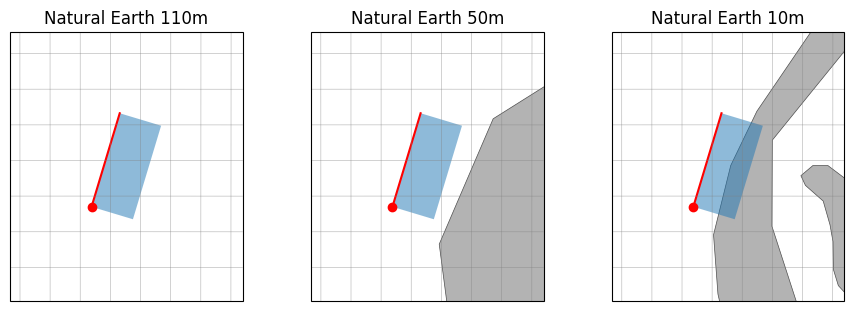

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(11, 3.5), subplot_kw=dict(projection=grid.projection))

for ax, scale in zip(axs, ["110m", "50m", "10m"]):
    ax.add_feature(cfeature.LAND.with_scale(scale), facecolor="0.7", edgecolor="0.3", linewidth=0.5)
    grid.plot(ax=ax, scale=None, buffer=5000)
    ax.set_title(f"Natural Earth {scale}")

---
## 5. Expanding the Grid

Grid expansion is useful for extending boundaries to accommodate:
- Wave boundary conditions (offshore extension)
- Lateral boundary conditions (left/right extension)
- Buffer zones for data interpolation

### Basic Expansion

In [21]:
# Expand offshore by 30 cells, laterally by 5 cells each side
grid_extended = grid.expand(left=5, right=5, front=30)

print(f"Original:  {grid.nx} × {grid.ny} cells")
print(f"Extended:  {grid_extended.nx} × {grid_extended.ny} cells")

Original:  270 × 305 cells
Extended:  300 × 315 cells


Text(0.5, 1.0, 'Yellow = Extended, Black = Original')

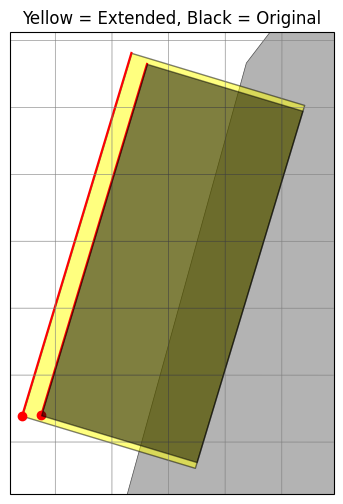

In [22]:
# Visualise the expansion
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection=grid.projection))

grid_extended.plot(ax=ax, scale="i", grid_kwargs=dict(facecolor="yellow", edgecolor="k", alpha=0.5, zorder=2))
grid.plot(ax=ax, grid_kwargs=dict(facecolor="black", edgecolor="k", alpha=0.5, zorder=3))

ax.set_title("Yellow = Extended, Black = Original")

### Expansion Options

Different expansion configurations for different purposes:

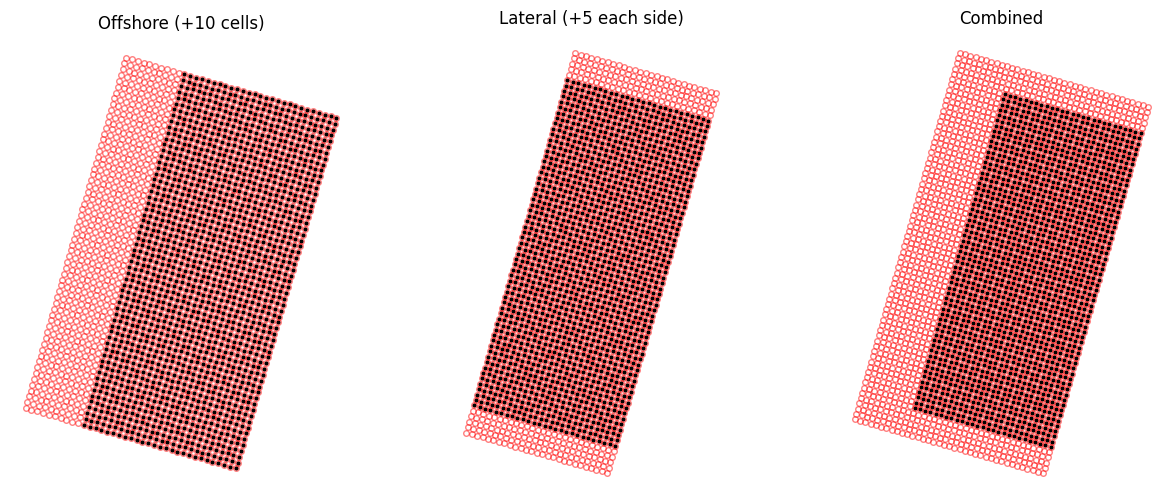

In [23]:
# Create a coarser grid for clearer visualisation
grid_coarse = RegularGrid(
    ori=GeoPoint(x=115.5875, y=-32.646, crs="epsg:4326"),
    alfa=344.0,
    dx=100, dy=100,
    nx=27, ny=61,
    crs=28350,
)

def plot_expansion(ax, original, expanded, title):
    """Plot original (black) and expanded (red circles) grids."""
    ax.plot(original.x, original.y, "k.", markersize=4, alpha=1.0, label="Original")
    ax.plot(expanded.x, expanded.y, "ro", markerfacecolor="none", markersize=4, alpha=0.5, label="Expanded")
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# Offshore only
plot_expansion(axs[0], grid_coarse, grid_coarse.expand(front=10), "Offshore (+10 cells)")

# Lateral only
plot_expansion(axs[1], grid_coarse, grid_coarse.expand(left=5, right=5), "Lateral (+5 each side)")

# Combined
plot_expansion(axs[2], grid_coarse, grid_coarse.expand(front=10, left=5, right=5), "Combined")

---
## 6. Saving and Loading Grids

Grids can be saved to various formats for sharing or visualization in GIS software.

### Save as KML (for Google Earth)

In [24]:
grid.to_file("grid.kml", driver="KML")
print("Saved grid.kml")

2026-01-10 18:19:13 [INFO] pyogrio._io         : Created 1 records


Saved grid.kml


The saved file can be opened in Google Earth or other GIS software:

![Grid on imagery](grid_on_imagery.png)

### Save Boundaries Only

For large grids, saving just the boundary polygon is more efficient:

In [25]:
import geopandas as gpd

gdf_boundary = gpd.GeoSeries(grid.boundary(), crs=grid.crs)
gdf_boundary.to_file("grid_boundaries.kml", driver="KML")
print("Saved grid_boundaries.kml")

2026-01-10 18:19:15 [INFO] pyogrio._io         : Created 1 records


Saved grid_boundaries.kml


### Load Grid from File

The full grid file stores metadata allowing recreation of the grid object:

Loaded grid: 270 × 305 cells


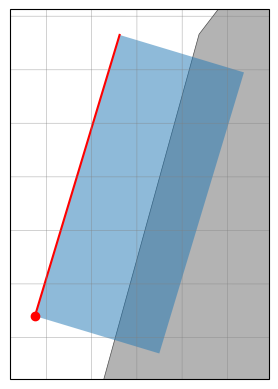

In [26]:
grid_loaded = RegularGrid.from_file("grid.kml")
print(f"Loaded grid: {grid_loaded.nx} × {grid_loaded.ny} cells")

ax = grid_loaded.plot(scale="i")

---
## 7. Summary

### Key Classes

| Class | Purpose |
|-------|---------|
| `GeoPoint` | Define coordinates with CRS, supports reprojection |
| `RegularGrid` | Define computational domain with origin, rotation, resolution |

### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `ori` | Grid origin (GeoPoint) |
| `alfa` | Rotation angle from East (degrees) |
| `dx`, `dy` | Cell dimensions (metres) |
| `nx`, `ny` | Number of cells |
| `crs` | Coordinate reference system |

### Key Methods

| Method | Description |
|--------|-------------|
| `plot()` | Visualise grid with coastlines |
| `expand()` | Extend grid boundaries |
| `to_file()` | Save to KML/GeoJSON/etc |
| `from_file()` | Load from saved file |

### Useful Attributes

| Attribute | Description |
|-----------|-------------|
| `x0`, `y0` | Origin in grid CRS |
| `offshore` | Centre of offshore boundary |
| `centre` | Grid centre point |
| `front`, `back`, `left`, `right` | Boundary coordinates |
| `gdf` | GeoDataFrame of all cells |
| `transform` | Cartopy transform for plotting |

### Next Steps

- See the **Bathymetry** tutorial for interpolating depth data onto the grid
- See the **Wave Boundary** tutorials for setting up boundary conditions